In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/time_series_final_project")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DIR / "train.csv"
TEST_PATH = RAW_DIR / "test.csv"
SUBMISSION_PATH = RAW_DIR / "sample_submission.csv"

print(TRAIN_PATH.exists(), TEST_PATH.exists(), SUBMISSION_PATH.exists())

True True True


**Загружаем датасет**

**Датасет содержит 500 связанных временных рядов: 10 магазинов × 50 товаров.
Каждый ряд — ежедневные продажи конкретного товара в конкретном магазине.
Период наблюдений: 2013-01-01 — 2017-12-31**

**Предметная область:** прогнозирование спроса / продаж в розничной торговле.

**Целевая переменная:** sales.

**Частота:** daily.

**Тип задачи:** multiseries time series forecasting.

**Количество рядов:** 500.

Нужно зафиксировать:

**Горизонт прогнозирования:** 28 дней.

**Режим:** offline forecasting.

**Глобальные модели:** нужны, потому что есть 500 связанных рядов.

**Метрики:** MAE, RMSE, sMAPE.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

df_raw = pd.read_csv(TRAIN_PATH)

display(df_raw.head())
print("Размер train.csv:", df_raw.shape)

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


Размер train.csv: (913000, 4)


**Проверяем его структуру**

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


**Базовая статистика**

In [ ]:
display(df_raw.describe(include="all"))

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
unique,1826,NaN,NaN,NaN
top,2017-12-31,NaN,NaN,NaN
freq,500,NaN,NaN,NaN
mean,NaN,5.500000,25.500000,52.250287
std,NaN,2.872283,14.430878,28.801144
min,NaN,1.000000,1.000000,0.000000
25%,NaN,3.000000,13.000000,30.000000
50%,NaN,5.500000,25.500000,47.000000
75%,NaN,8.000000,38.000000,70.000000


**Проверяем пропуски и дубликаты**

In [ ]:
print("Пропуски по колонкам:")
display(df_raw.isna().sum())

print("Количество полных дубликатов:")
print(df_raw.duplicated().sum())

Пропуски по колонкам:


,0
date,0
store,0
item,0
sales,0


Количество полных дубликатов:
0


**Приводим к формату временных рядов**
Для statsforecast, mlforecast, neuralforecast нам нужен формат:
unique_id | ds | y
где:
unique_id = store + item
ds = date
y = sales

In [ ]:
df = df_raw.copy()

df["date"] = pd.to_datetime(df["date"])

df["unique_id"] = (
    "store_" + df["store"].astype(str) +
    "_item_" + df["item"].astype(str)
)

df = df.rename(columns={
    "date": "ds",
    "sales": "y"
})

df = df[["unique_id", "ds", "y", "store", "item"]]
df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

display(df.head())
display(df.tail())

,unique_id,ds,y,store,item
0,store_10_item_1,2013-01-01,14,10,1
1,store_10_item_1,2013-01-02,14,10,1
2,store_10_item_1,2013-01-03,16,10,1
3,store_10_item_1,2013-01-04,17,10,1
4,store_10_item_1,2013-01-05,12,10,1


,unique_id,ds,y,store,item
912995,store_9_item_9,2017-12-27,44,9,9
912996,store_9_item_9,2017-12-28,48,9,9
912997,store_9_item_9,2017-12-29,54,9,9
912998,store_9_item_9,2017-12-30,59,9,9
912999,store_9_item_9,2017-12-31,50,9,9


In [ ]:
print(df.dtypes)

unique_id            object
ds           datetime64[ns]
y                     int64
store                 int64
item                  int64
dtype: object


**Проверяем количество рядов и период**

In [ ]:
print("Количество временных рядов:", df["unique_id"].nunique())
print("Количество магазинов:", df["store"].nunique())
print("Количество товаров:", df["item"].nunique())

print("Минимальная дата:", df["ds"].min())
print("Максимальная дата:", df["ds"].max())
print("Количество наблюдений:", len(df))

series_lengths = df.groupby("unique_id").size()

print("Минимальная длина ряда:", series_lengths.min())
print("Максимальная длина ряда:", series_lengths.max())
print("Средняя длина ряда:", series_lengths.mean())

Количество временных рядов: 500
Количество магазинов: 10
Количество товаров: 50
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2017-12-31 00:00:00
Количество наблюдений: 913000
Минимальная длина ряда: 1826
Максимальная длина ряда: 1826
Средняя длина ряда: 1826.0


**Проверяем регулярность временных рядов**

In [ ]:
date_check = (
    df.groupby("unique_id")["ds"]
    .agg(["min", "max", "count"])
    .reset_index()
)

date_check["expected_count"] = (
    date_check["max"] - date_check["min"]
).dt.days + 1

date_check["missing_dates"] = date_check["expected_count"] - date_check["count"]

display(date_check.head())

print("Рядов с пропущенными датами:", (date_check["missing_dates"] > 0).sum())
display(date_check["missing_dates"].describe())

,unique_id,min,max,count,expected_count,missing_dates
0,store_10_item_1,2013-01-01,2017-12-31,1826,1826,0
1,store_10_item_10,2013-01-01,2017-12-31,1826,1826,0
2,store_10_item_11,2013-01-01,2017-12-31,1826,1826,0
3,store_10_item_12,2013-01-01,2017-12-31,1826,1826,0
4,store_10_item_13,2013-01-01,2017-12-31,1826,1826,0


Рядов с пропущенными датами: 0


,missing_dates
count,500.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


**Сохраняем подготовленный датасет**

In [ ]:
PREPARED_PATH = PROCESSED_DIR / "store_item_sales_prepared.csv"

df.to_csv(PREPARED_PATH, index=False)

print("Сохранено:", PREPARED_PATH)

Сохранено: /content/drive/MyDrive/time_series_final_project/data/processed/store_item_sales_prepared.csv


**Базовое EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

**Общая динамика продаж по дням**

,ds,total_sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


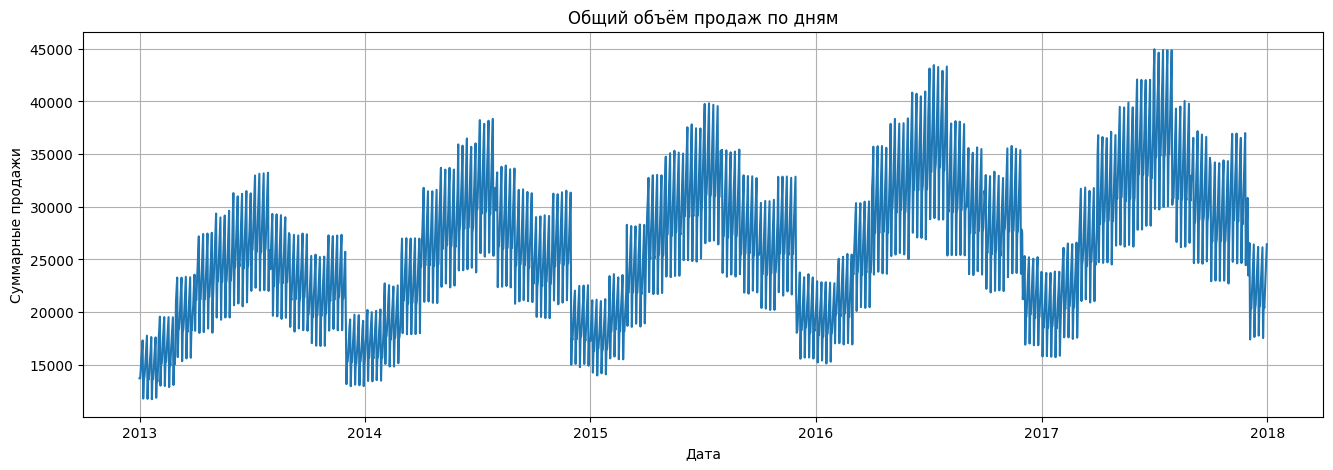

In [ ]:
daily_sales = (
    df.groupby("ds", as_index=False)["y"]
    .sum()
    .rename(columns={"y": "total_sales"})
)

display(daily_sales.head())

plt.figure(figsize=(16, 5))
plt.plot(daily_sales["ds"], daily_sales["total_sales"])
plt.title("Общий объём продаж по дням")
plt.xlabel("Дата")
plt.ylabel("Суммарные продажи")
plt.show()

**Сохраним график:**

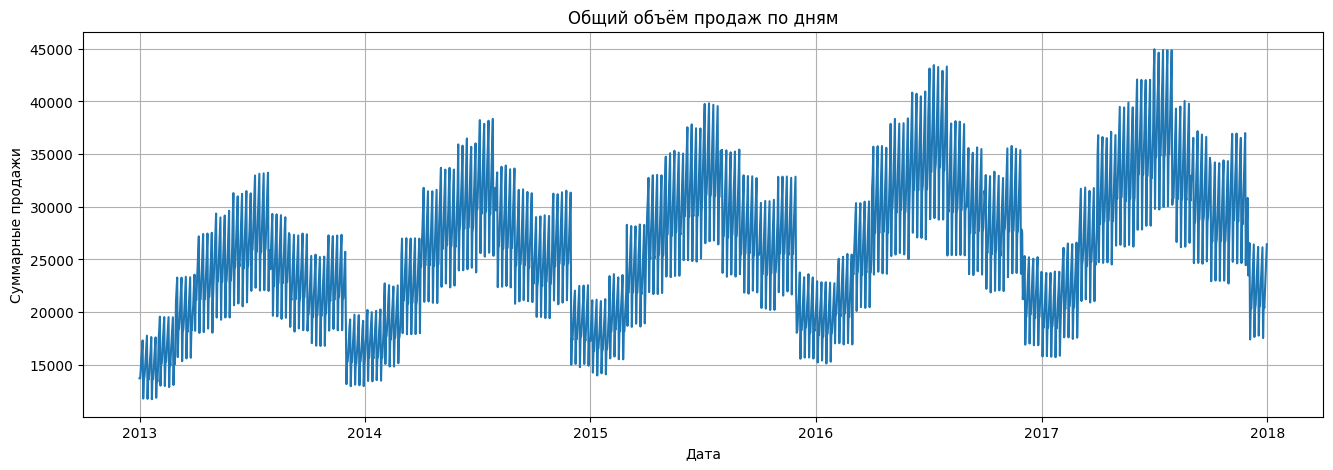

Сохранено: /content/drive/MyDrive/time_series_final_project/reports/figures/total_daily_sales.png


In [ ]:
fig_path = FIGURES_DIR / "total_daily_sales.png"

plt.figure(figsize=(16, 5))
plt.plot(daily_sales["ds"], daily_sales["total_sales"])
plt.title("Общий объём продаж по дням")
plt.xlabel("Дата")
plt.ylabel("Суммарные продажи")
plt.grid(True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено:", fig_path)

**Продажи по годам**

,year,total_sales
0,2013,7941243
1,2014,9135482
2,2015,9536887
3,2016,10357160
4,2017,10733740


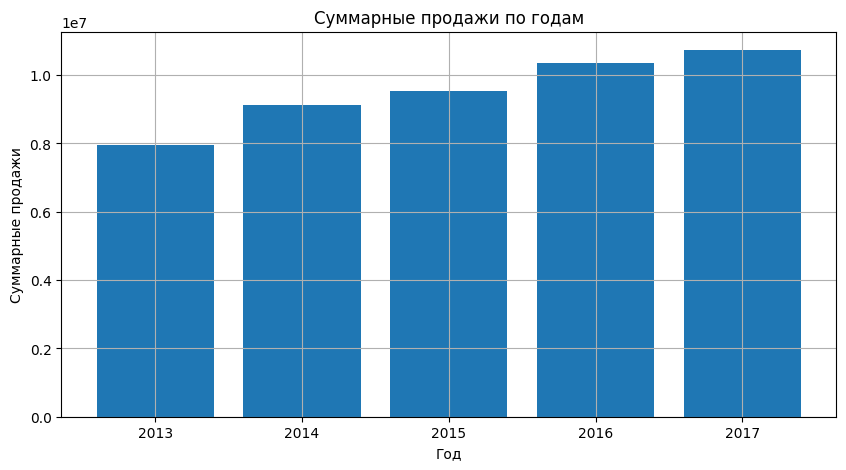

In [ ]:
df_eda = df.copy()
df_eda["year"] = df_eda["ds"].dt.year
df_eda["month"] = df_eda["ds"].dt.month
df_eda["dayofweek"] = df_eda["ds"].dt.dayofweek
df_eda["day_name"] = df_eda["ds"].dt.day_name()

year_sales = (
    df_eda.groupby("year", as_index=False)["y"]
    .sum()
    .rename(columns={"y": "total_sales"})
)

display(year_sales)

plt.figure(figsize=(10, 5))
plt.bar(year_sales["year"], year_sales["total_sales"])
plt.title("Суммарные продажи по годам")
plt.xlabel("Год")
plt.ylabel("Суммарные продажи")
plt.show()

**Сезонность по месяцам**

,month,avg_sales
0,1,35.524503
1,2,39.378397
2,3,47.305574
3,4,55.152893
4,5,59.128219
5,6,63.025480
6,7,66.998619
7,8,59.105226
8,9,55.072760
9,10,51.193806


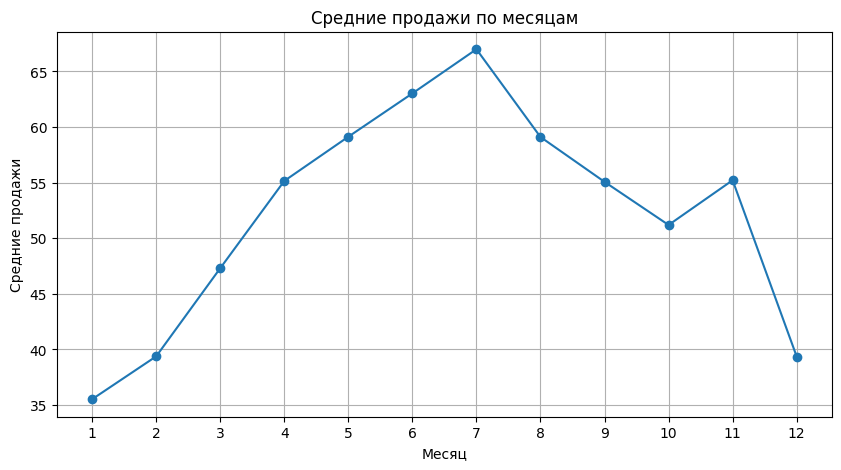

In [ ]:
month_sales = (
    df_eda.groupby("month", as_index=False)["y"]
    .mean()
    .rename(columns={"y": "avg_sales"})
)

display(month_sales)

plt.figure(figsize=(10, 5))
plt.plot(month_sales["month"], month_sales["avg_sales"], marker="o")
plt.title("Средние продажи по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средние продажи")
plt.xticks(range(1, 13))
plt.show()

**Сезонность по дням недели**

,day_name,avg_sales
1,Monday,41.429638
5,Tuesday,48.225908
6,Wednesday,48.368506
4,Thursday,51.723218
0,Friday,55.157249
2,Saturday,58.662697
3,Sunday,62.143333


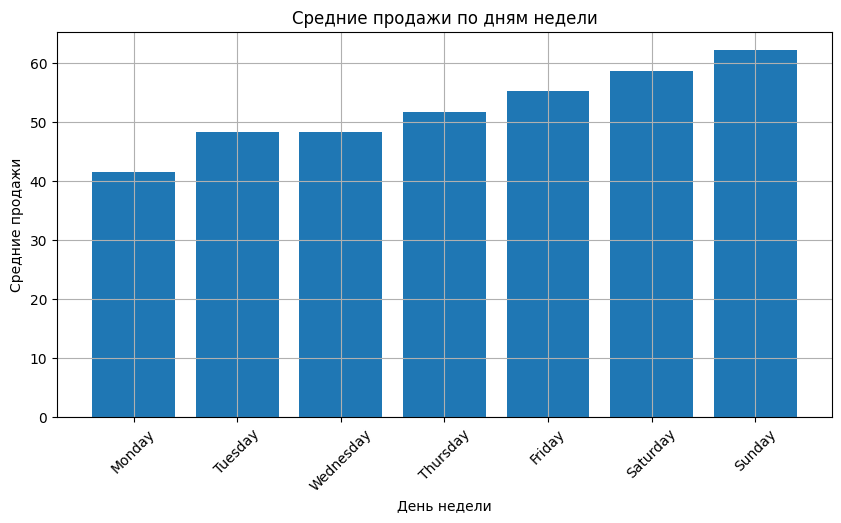

In [ ]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_sales = (
    df_eda.groupby("day_name", as_index=False)["y"]
    .mean()
    .rename(columns={"y": "avg_sales"})
)

dow_sales["day_name"] = pd.Categorical(dow_sales["day_name"], categories=dow_order, ordered=True)
dow_sales = dow_sales.sort_values("day_name")

display(dow_sales)

plt.figure(figsize=(10, 5))
plt.bar(dow_sales["day_name"].astype(str), dow_sales["avg_sales"])
plt.title("Средние продажи по дням недели")
plt.xlabel("День недели")
plt.ylabel("Средние продажи")
plt.xticks(rotation=45)
plt.show()

**Сравнение магазинов**

,store,total_sales
1,2,6120128
7,8,5856169
2,3,5435144
9,10,5360158
8,9,5025976
3,4,5012639
0,1,4315603
4,5,3631016
5,6,3627670
6,7,3320009


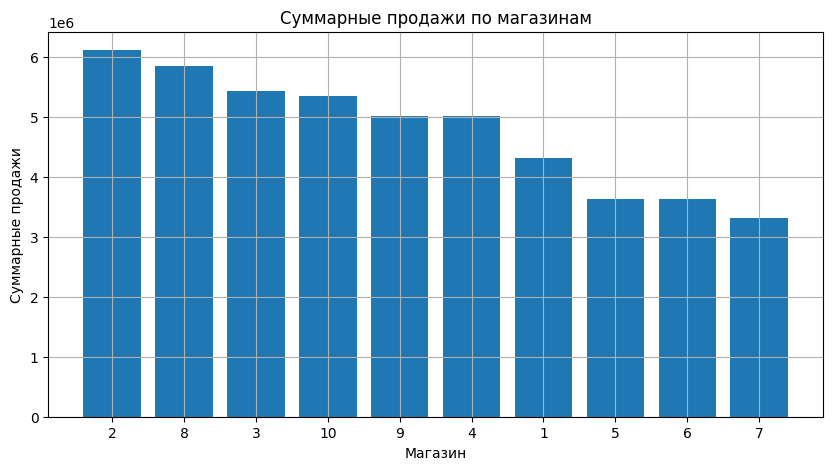

In [ ]:
store_sales = (
    df_eda.groupby("store", as_index=False)["y"]
    .sum()
    .rename(columns={"y": "total_sales"})
    .sort_values("total_sales", ascending=False)
)

display(store_sales)

plt.figure(figsize=(10, 5))
plt.bar(store_sales["store"].astype(str), store_sales["total_sales"])
plt.title("Суммарные продажи по магазинам")
plt.xlabel("Магазин")
plt.ylabel("Суммарные продажи")
plt.show()

**Сравнение товаров**

,item,total_sales
14,15,1607442
27,28,1604713
12,13,1539621
17,18,1538876
24,25,1473334
44,45,1471467
37,38,1470330
21,22,1469971
35,36,1406548
7,8,1405108


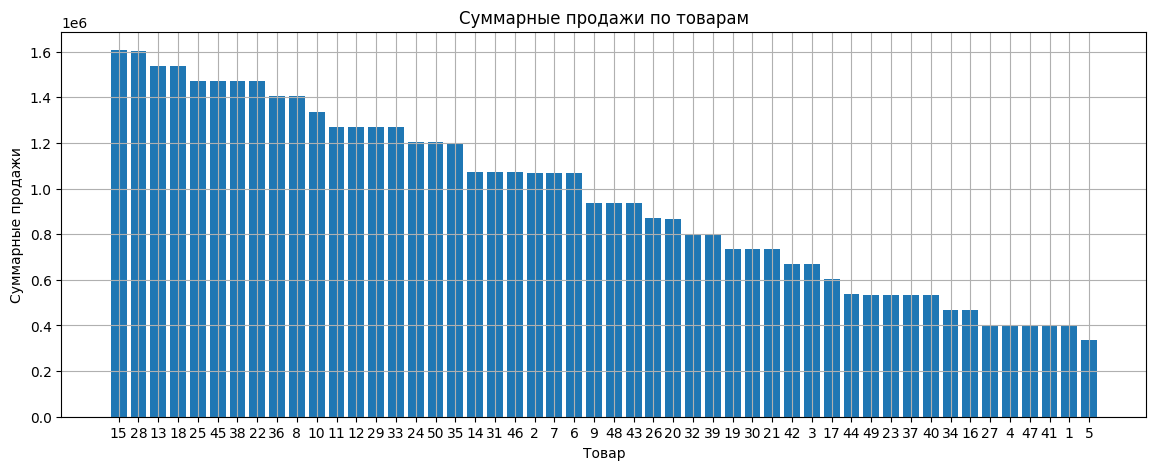

In [ ]:
item_sales = (
    df_eda.groupby("item", as_index=False)["y"]
    .sum()
    .rename(columns={"y": "total_sales"})
    .sort_values("total_sales", ascending=False)
)

display(item_sales.head(10))

plt.figure(figsize=(14, 5))
plt.bar(item_sales["item"].astype(str), item_sales["total_sales"])
plt.title("Суммарные продажи по товарам")
plt.xlabel("Товар")
plt.ylabel("Суммарные продажи")
plt.show()

**Пример одного временного ряда**

,unique_id,ds,y,store,item
91300,store_1_item_1,2013-01-01,13,1,1
91301,store_1_item_1,2013-01-02,11,1,1
91302,store_1_item_1,2013-01-03,14,1,1
91303,store_1_item_1,2013-01-04,13,1,1
91304,store_1_item_1,2013-01-05,10,1,1


,unique_id,ds,y,store,item
93121,store_1_item_1,2017-12-27,14,1,1
93122,store_1_item_1,2017-12-28,19,1,1
93123,store_1_item_1,2017-12-29,15,1,1
93124,store_1_item_1,2017-12-30,27,1,1
93125,store_1_item_1,2017-12-31,23,1,1


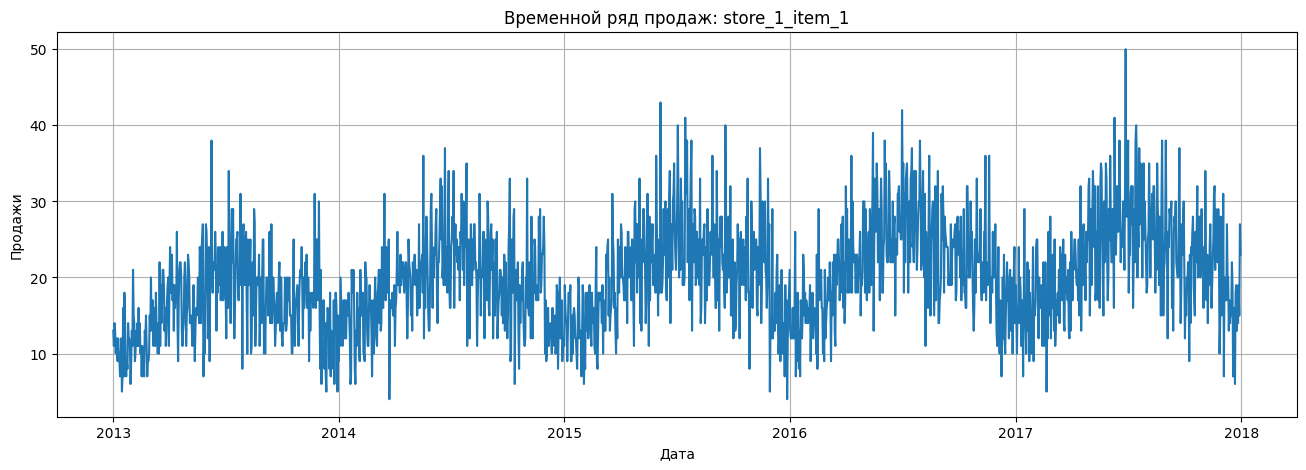

In [ ]:
one_id = "store_1_item_1"

one_series = df[df["unique_id"] == one_id].copy()

display(one_series.head())
display(one_series.tail())

plt.figure(figsize=(16, 5))
plt.plot(one_series["ds"], one_series["y"])
plt.title(f"Временной ряд продаж: {one_id}")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.show()

**Rolling mean для одного ряда**

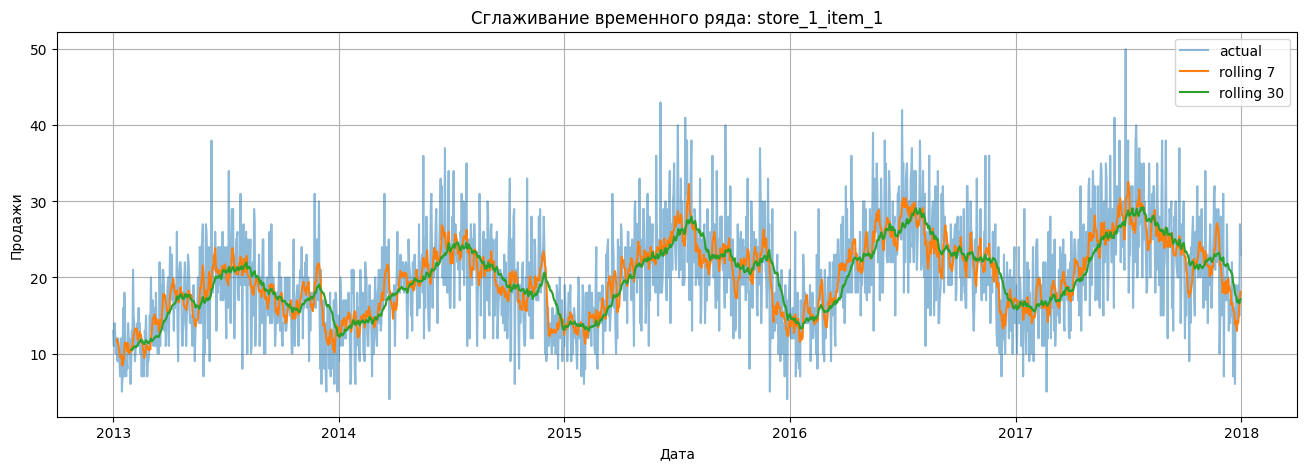

In [ ]:
one_series["rolling_7"] = one_series["y"].rolling(window=7).mean()
one_series["rolling_30"] = one_series["y"].rolling(window=30).mean()

plt.figure(figsize=(16, 5))
plt.plot(one_series["ds"], one_series["y"], label="actual", alpha=0.5)
plt.plot(one_series["ds"], one_series["rolling_7"], label="rolling 7")
plt.plot(one_series["ds"], one_series["rolling_30"], label="rolling 30")
plt.title(f"Сглаживание временного ряда: {one_id}")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.legend()
plt.show()

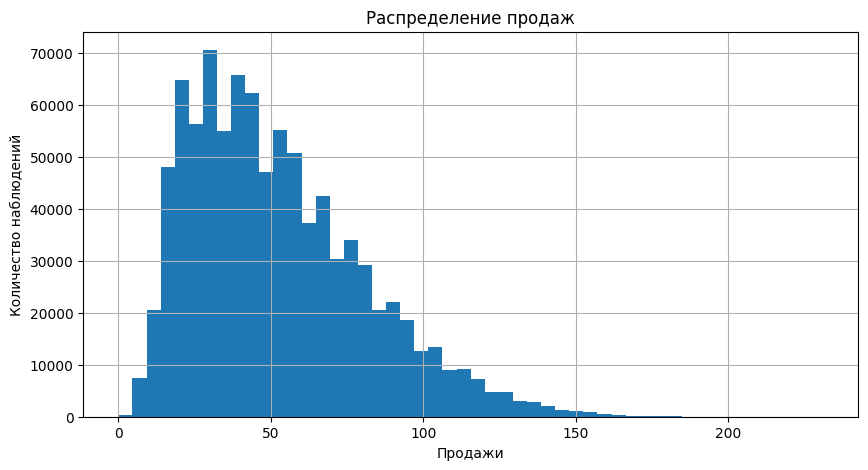

,y
count,913000.000000
mean,52.250287
std,28.801144
min,0.000000
25%,30.000000
50%,47.000000
75%,70.000000
max,231.000000


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["y"], bins=50)
plt.title("Распределение продаж")
plt.xlabel("Продажи")
plt.ylabel("Количество наблюдений")
plt.grid(True)
plt.show()

display(df["y"].describe())

**Распределение целевой переменной `sales` имеет правостороннюю асимметрию: основная масса наблюдений сосредоточена в диапазоне низких и средних продаж, при этом присутствует длинный правый хвост. Это означает, что в данных встречаются редкие периоды повышенного спроса, которые потенциально могут рассматриваться как всплески или аномальные значения.**

<Figure size 1200x500 with 0 Axes>

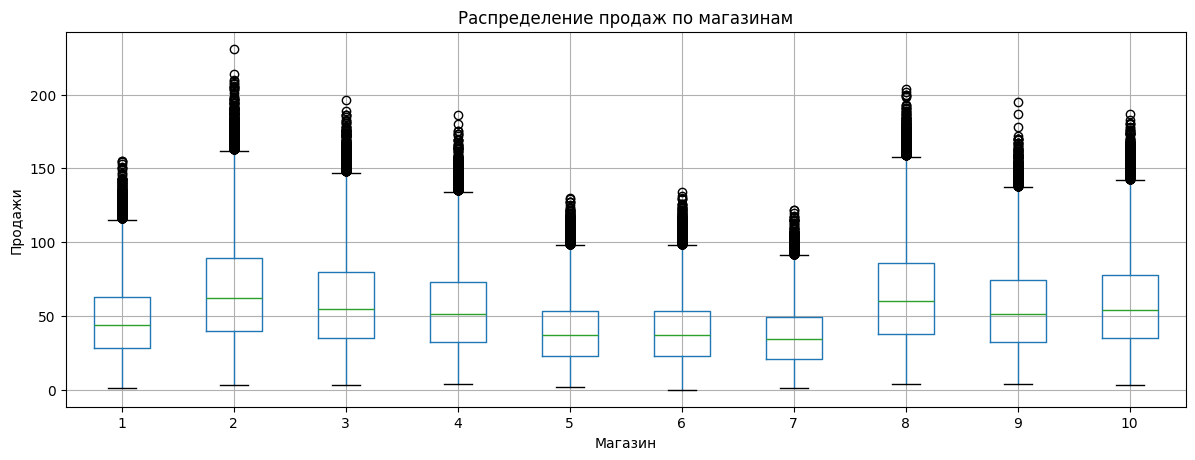

In [ ]:
plt.figure(figsize=(12, 5))
df_eda.boxplot(column="y", by="store")
plt.title("Распределение продаж по магазинам")
plt.suptitle("")
plt.xlabel("Магазин")
plt.ylabel("Продажи")
plt.show()

**Boxplot продаж по магазинам показывает различия в уровне спроса между магазинами. Наиболее высокие медианные продажи наблюдаются у магазинов 2 и 8, тогда как магазины 5, 6 и 7 имеют более низкий уровень продаж. Во всех магазинах присутствуют верхние выбросы, что указывает на отдельные дни или пары магазин–товар с необычно высоким спросом.**

In [ ]:
zero_sales = (
    df.groupby("unique_id")
    .agg(
        n_obs=("y", "size"),
        zero_count=("y", lambda x: (x == 0).sum()),
        min_sales=("y", "min"),
        mean_sales=("y", "mean"),
        max_sales=("y", "max"),
    )
    .reset_index()
)

zero_sales["zero_share"] = zero_sales["zero_count"] / zero_sales["n_obs"]

display(zero_sales.sort_values("zero_share", ascending=False).head(20))
display(zero_sales["zero_share"].describe())

print("Рядов с хотя бы одним нулём:", (zero_sales["zero_count"] > 0).sum())
print("Максимальная доля нулей в одном ряду:", zero_sales["zero_share"].max())

,unique_id,n_obs,zero_count,min_sales,mean_sales,max_sales,zero_share
333,store_6_item_4,1826,1,0,16.754107,39,0.000548
342,store_6_item_48,1826,0,11,39.052574,82,0.000000
341,store_6_item_47,1826,0,3,16.708653,41,0.000000
340,store_6_item_46,1826,0,13,44.539978,94,0.000000
339,store_6_item_45,1826,0,19,61.142935,118,0.000000
338,store_6_item_44,1826,0,4,22.322563,51,0.000000
337,store_6_item_43,1826,0,9,39.034502,80,0.000000
336,store_6_item_42,1826,0,7,27.893209,60,0.000000
335,store_6_item_41,1826,0,2,16.607338,37,0.000000
334,store_6_item_40,1826,0,3,22.180175,51,0.000000


,zero_share
count,500.000000
mean,0.000001
std,0.000024
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.000548


Рядов с хотя бы одним нулём: 1
Максимальная доля нулей в одном ряду: 0.000547645125958379


### Анализ нулевых продаж

Дополнительно была рассчитана доля нулевых продаж для каждого временного ряда `unique_id`. Из 500 временных рядов только один ряд (`store_6_item_4`) содержит одно нулевое значение за 1826 наблюдений. Максимальная доля нулевых продаж составляет 0.000548.

Следовательно, выраженная проблема прерывистого спроса (intermittent demand) в датасете отсутствует. Это позволяет использовать стандартные методы прогнозирования временных рядов и метрики качества без отдельной адаптации под большое количество нулевых значений.

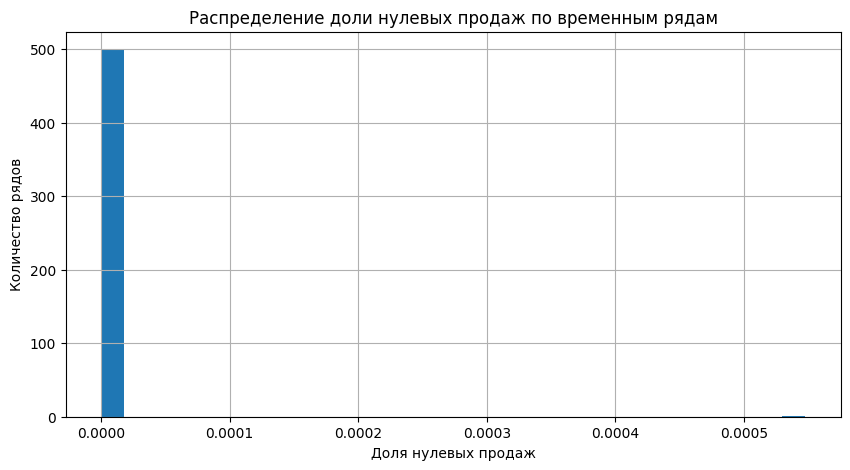

Сохранено: /content/drive/MyDrive/time_series_final_project/reports/figures/zero_sales_share_distribution.png


In [ ]:
fig_path = FIGURES_DIR / "zero_sales_share_distribution.png"

plt.figure(figsize=(10, 5))
plt.hist(zero_sales["zero_share"], bins=30)
plt.title("Распределение доли нулевых продаж по временным рядам")
plt.xlabel("Доля нулевых продаж")
plt.ylabel("Количество рядов")
plt.grid(True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено:", fig_path)

**По текущим графикам уже можно сделать выводы:**
1) Есть общий восходящий тренд.

2) Есть выраженная годовая сезонность.

3) Есть недельная сезонность.

4) Распределение продаж асимметрично вправо.

5) Есть редкие высокие значения продаж.

6) Магазины отличаются по масштабу спроса.

7) Так как нулевые продажи практически отсутствуют, нет необходимости отдельно применять специализированные методы для прерывистого спроса, например Croston-подобные подходы. Основной фокус можно сделать на моделировании тренда, недельной и годовой сезонности, а также различий масштаба между магазинами и товарами.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

**Выбираем один временной ряд**

In [ ]:
one_id = "store_1_item_1"

one_series = (
    df[df["unique_id"] == one_id]
    .copy()
    .sort_values("ds")
)

one_series = one_series.set_index("ds")

display(one_series.head())
display(one_series.tail())

y = one_series["y"]

,unique_id,y,store,item
ds,,,,
2013-01-01,store_1_item_1,13,1,1
2013-01-02,store_1_item_1,11,1,1
2013-01-03,store_1_item_1,14,1,1
2013-01-04,store_1_item_1,13,1,1
2013-01-05,store_1_item_1,10,1,1


,unique_id,y,store,item
ds,,,,
2017-12-27,store_1_item_1,14,1,1
2017-12-28,store_1_item_1,19,1,1
2017-12-29,store_1_item_1,15,1,1
2017-12-30,store_1_item_1,27,1,1
2017-12-31,store_1_item_1,23,1,1


**Для детального анализа структуры временного ряда был выбран ряд `store_1_item_1`, соответствующий продажам товара 1 в магазине 1. Этот ряд используется для ACF/PACF, STL-декомпозиции и проверки стационарности.**

**ACF/PACF**

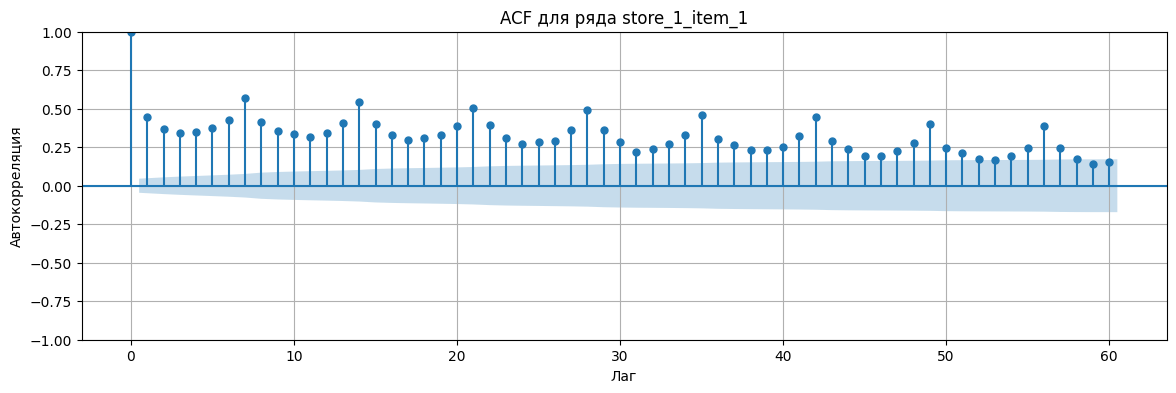

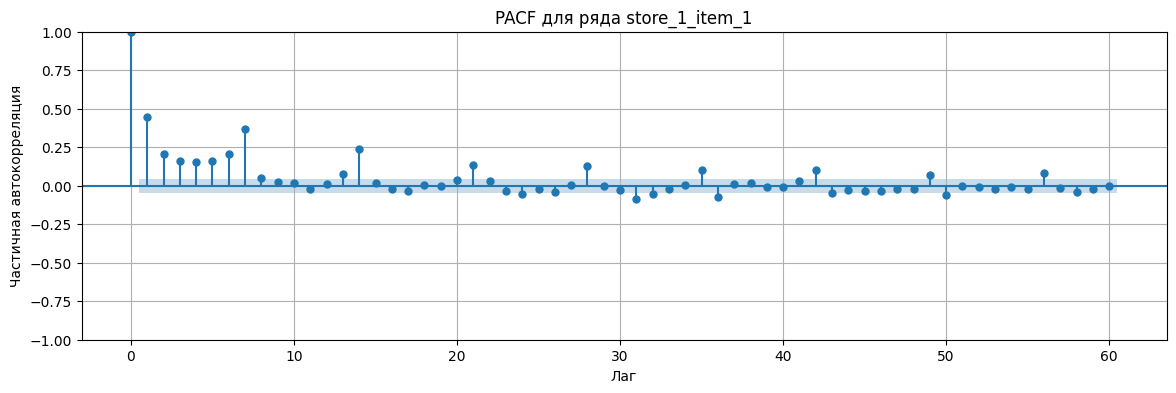

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(y, lags=60, ax=ax)
ax.set_title(f"ACF для ряда {one_id}")
ax.set_xlabel("Лаг")
ax.set_ylabel("Автокорреляция")
plt.grid(True)
plt.savefig(FIGURES_DIR / "acf_store_1_item_1.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
plot_pacf(y, lags=60, method="ywm", ax=ax)
ax.set_title(f"PACF для ряда {one_id}")
ax.set_xlabel("Лаг")
ax.set_ylabel("Частичная автокорреляция")
plt.grid(True)
plt.savefig(FIGURES_DIR / "pacf_store_1_item_1.png", dpi=150, bbox_inches="tight")
plt.show()

**STL-декомпозиция**

Так как данные дневные, сначала используем недельную сезонность period=7

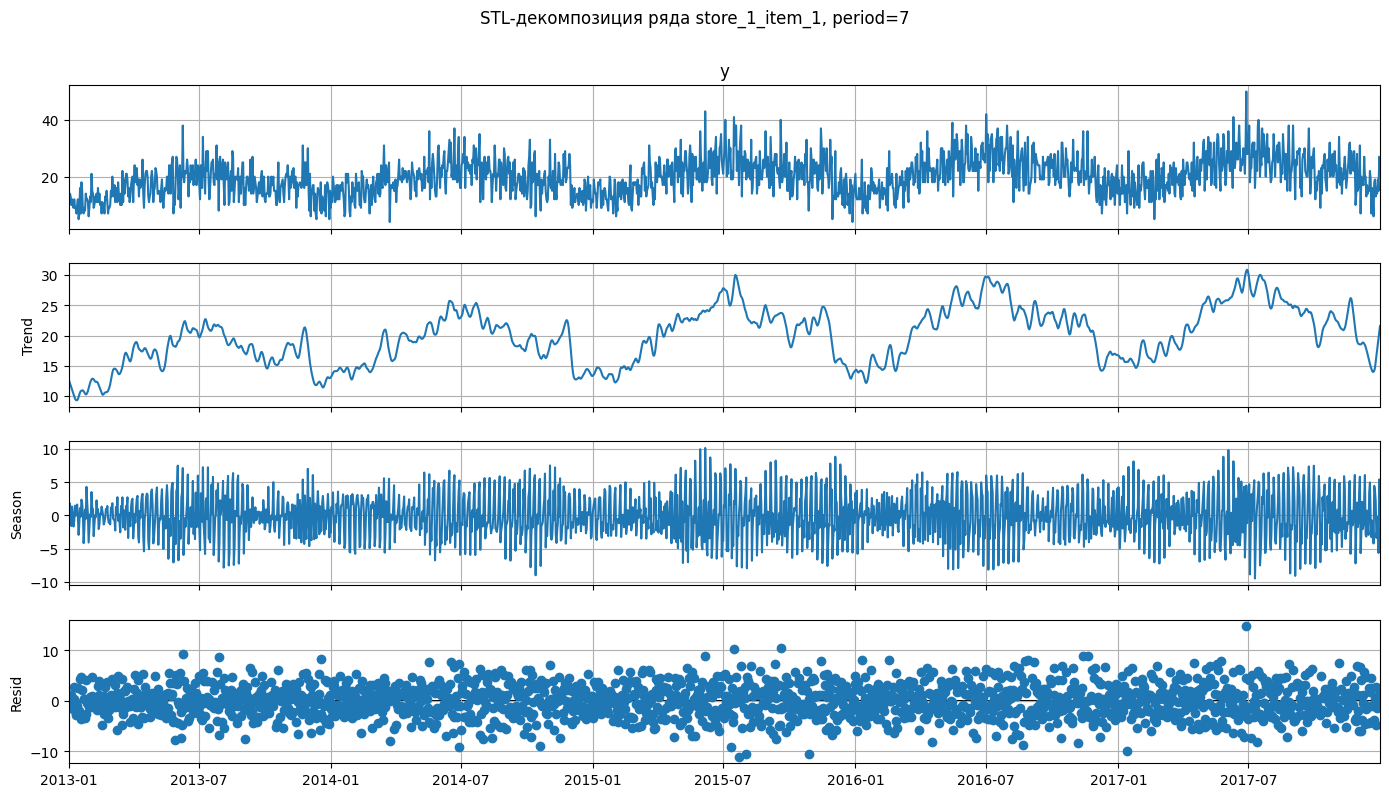

In [ ]:
stl_weekly = STL(y, period=7)
stl_weekly_result = stl_weekly.fit()

fig = stl_weekly_result.plot()
fig.set_size_inches(14, 8)
plt.suptitle(f"STL-декомпозиция ряда {one_id}, period=7", y=1.02)
plt.savefig(FIGURES_DIR / "stl_weekly_store_1_item_1.png", dpi=150, bbox_inches="tight")
plt.show()

Дополнительно можно сделать годовую сезонность. Для дневных данных годовой период примерно 365.

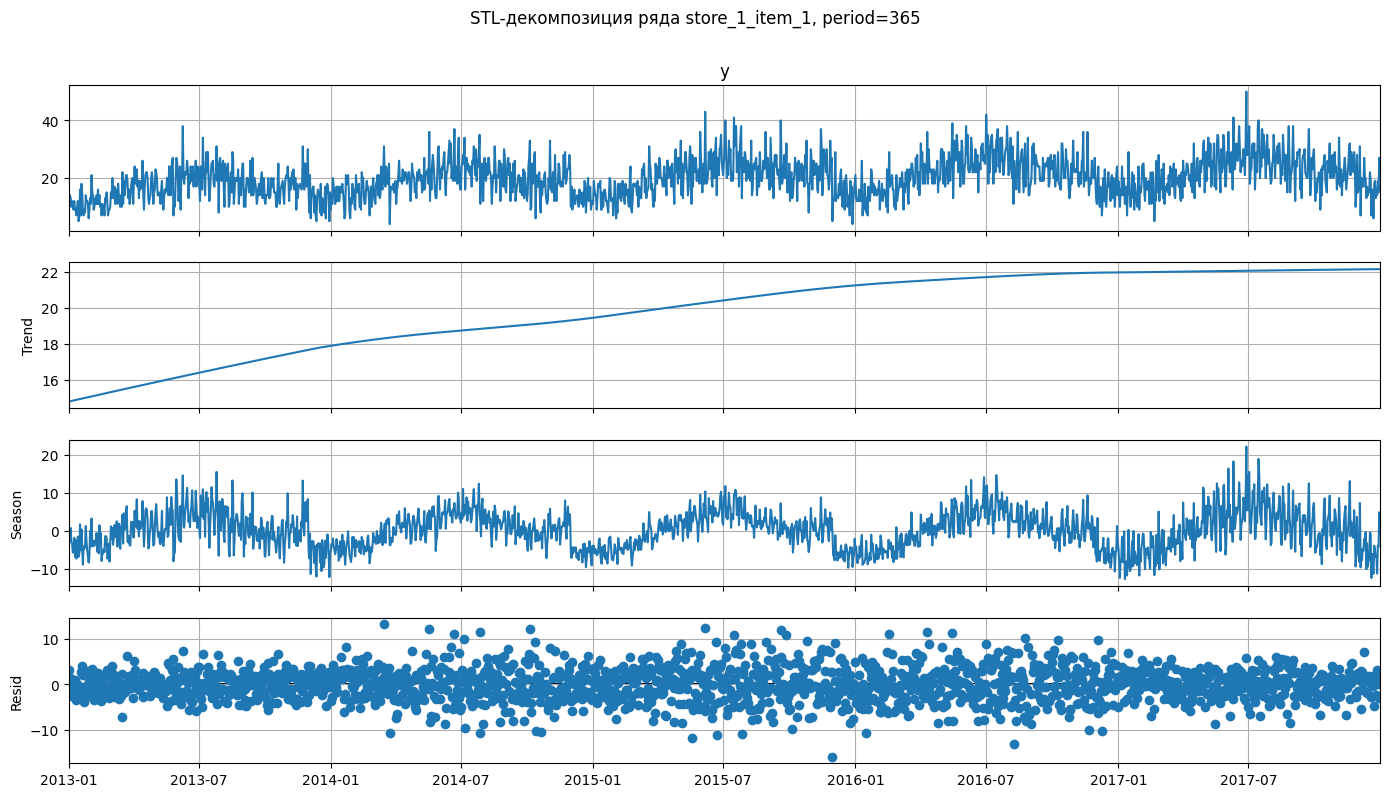

In [ ]:
stl_yearly = STL(y, period=365)
stl_yearly_result = stl_yearly.fit()

fig = stl_yearly_result.plot()
fig.set_size_inches(14, 8)
plt.suptitle(f"STL-декомпозиция ряда {one_id}, period=365", y=1.02)
plt.savefig(FIGURES_DIR / "stl_yearly_store_1_item_1.png", dpi=150, bbox_inches="tight")
plt.show()

**ADF-тест исходного ряда**

In [ ]:
def run_adf_test(series, name):
    result = adfuller(series.dropna())

    output = {
        "series": name,
        "adf_statistic": result[0],
        "p_value": result[1],
        "used_lag": result[2],
        "n_obs": result[3],
        "critical_1%": result[4]["1%"],
        "critical_5%": result[4]["5%"],
        "critical_10%": result[4]["10%"],
    }

    if result[1] < 0.05:
        output["conclusion"] = "stationary"
    else:
        output["conclusion"] = "non-stationary"

    return output

In [ ]:
adf_original = run_adf_test(y, "original")

adf_original_df = pd.DataFrame([adf_original])
display(adf_original_df)

,series,adf_statistic,p_value,used_lag,n_obs,critical_1%,critical_5%,critical_10%,conclusion
0,original,-3.157671,0.022569,23,1802,-3.433984,-2.863145,-2.567625,stationary


**Интерпретация:**

# ADF-тест формально отвергает гипотезу о единичном корне, однако визуальный анализ, ACF и STL-декомпозиция показывают наличие трендовой и сезонной структуры. Поэтому для классических моделей ARIMA/SARIMA дополнительно рассматриваются первое и сезонное дифференцирование.

In [ ]:
# ADF-тест по всем временным рядам

from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

adf_results_all = []

for uid in df["unique_id"].unique():
    series = (
        df[df["unique_id"] == uid]
        .sort_values("ds")["y"]
        .dropna()
    )

    try:
        result = adfuller(series)
        adf_results_all.append({
            "unique_id": uid,
            "adf_statistic": result[0],
            "p_value": result[1],
            "used_lag": result[2],
            "n_obs": result[3],
            "is_stationary_005": result[1] < 0.05
        })
    except Exception as e:
        adf_results_all.append({
            "unique_id": uid,
            "adf_statistic": np.nan,
            "p_value": np.nan,
            "used_lag": np.nan,
            "n_obs": len(series),
            "is_stationary_005": False,
            "error": str(e)
        })

adf_all_df = pd.DataFrame(adf_results_all)

display(adf_all_df.head())
display(adf_all_df["p_value"].describe())

stationary_share = adf_all_df["is_stationary_005"].mean()

print(f"Доля рядов, стационарных по ADF при p < 0.05: {stationary_share:.2%}")

adf_all_df.to_csv(PROCESSED_DIR / "adf_results_all_series.csv", index=False)

,unique_id,adf_statistic,p_value,used_lag,n_obs,is_stationary_005
0,store_10_item_1,-3.290753,0.015297,22,1803,True
1,store_10_item_10,-3.070166,0.028841,24,1801,True
2,store_10_item_11,-2.947980,0.040046,25,1800,True
3,store_10_item_12,-2.785085,0.060436,22,1803,False
4,store_10_item_13,-2.800016,0.058272,23,1802,False


,p_value
count,500.000000
mean,0.033332
std,0.014672
min,0.006115
25%,0.022953
50%,0.031438
75%,0.042785
max,0.083219


Доля рядов, стационарных по ADF при p < 0.05: 86.80%


# 434 из 500 рядов формально признаются стационарными по ADF-тесту на уровне значимости 5%

**Дифференцирование ряда**

1. Обычное первое дифференцирование: y[t] - y[t-1]
2. Сезонное недельное дифференцирование: y[t] - y[t-7]

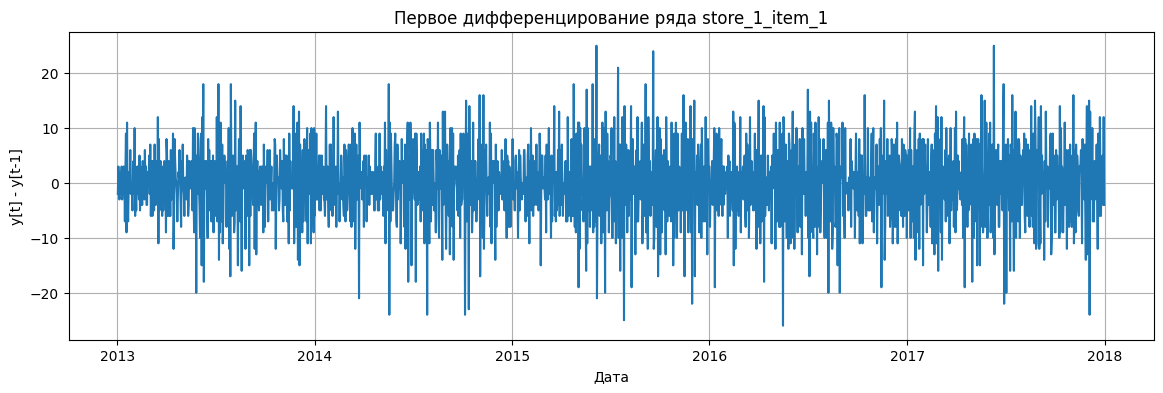

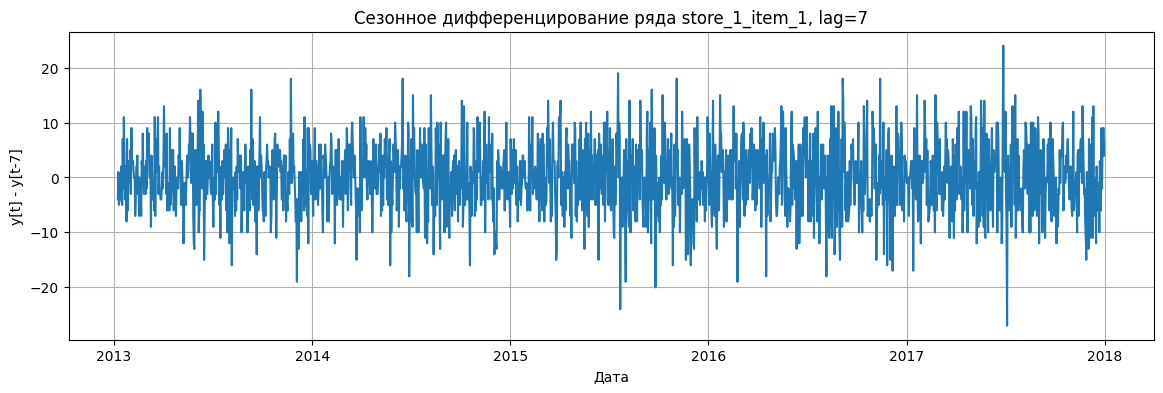

In [ ]:
one_series["diff_1"] = one_series["y"].diff(1)
one_series["diff_7"] = one_series["y"].diff(7)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one_series.index, one_series["diff_1"])
ax.set_title(f"Первое дифференцирование ряда {one_id}")
ax.set_xlabel("Дата")
ax.set_ylabel("y[t] - y[t-1]")
plt.grid(True)
plt.savefig(FIGURES_DIR / "diff_1_store_1_item_1.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one_series.index, one_series["diff_7"])
ax.set_title(f"Сезонное дифференцирование ряда {one_id}, lag=7")
ax.set_xlabel("Дата")
ax.set_ylabel("y[t] - y[t-7]")
plt.grid(True)
plt.savefig(FIGURES_DIR / "diff_7_store_1_item_1.png", dpi=150, bbox_inches="tight")
plt.show()

# Несмотря на результат ADF-теста, сезонное дифференцирование с лагом 7 рассматривается как полезное преобразование для ARIMA/SARIMA, так как ACF и STL показывают устойчивую недельную сезонность.

# STL с периодом 365 использовалась только для визуальной оценки годовой сезонности. Для дальнейшего моделирования годовую сезонность рациональнее учитывать через календарные признаки или Fourier-признаки, а недельную сезонность — через лаги 7, 14, 28 и сезонные модели.

**ADF-тест после дифференцирования**

In [ ]:
adf_diff_1 = run_adf_test(one_series["diff_1"], "first_difference")
adf_diff_7 = run_adf_test(one_series["diff_7"], "seasonal_difference_7")

adf_results = pd.DataFrame([
    adf_original,
    adf_diff_1,
    adf_diff_7
])

display(adf_results)

adf_results.to_csv(PROCESSED_DIR / "adf_results_store_1_item_1.csv", index=False)

,series,adf_statistic,p_value,used_lag,n_obs,critical_1%,critical_5%,critical_10%,conclusion
0,original,-3.157671,2.256938e-02,23,1802,-3.433984,-2.863145,-2.567625,stationary
1,first_difference,-12.676794,1.210928e-23,22,1802,-3.433984,-2.863145,-2.567625,stationary
2,seasonal_difference_7,-8.944407,9.070149e-15,24,1794,-3.434000,-2.863152,-2.567628,stationary


**Краткий автоматический вывод**

In [ ]:
for _, row in adf_results.iterrows():
    print(f"{row['series']}: p-value = {row['p_value']:.5f}, conclusion = {row['conclusion']}")

original: p-value = 0.02257, conclusion = stationary
first_difference: p-value = 0.00000, conclusion = stationary
seasonal_difference_7: p-value = 0.00000, conclusion = stationary


In [ ]:
print("Итоговая интерпретация:")
print("Для исходного ряда p-value < 0.05, поэтому нулевая гипотеза ADF-теста")
print("о наличии единичного корня отвергается.")
print("Следовательно, исходный ряд можно считать стационарным на уровне значимости 5%.")
print("После первого и сезонного дифференцирования p-value также близки к нулю,")
print("что подтверждает стационарность преобразованных рядов.")
print("Так как исходный ряд уже стационарен по ADF-тесту, дифференцирование")
print("не является обязательным для достижения стационарности, но может быть")
print("использовано при настройке ARIMA/SARIMA и анализе сезонной структуры.")

Итоговая интерпретация:
Для исходного ряда p-value < 0.05, поэтому нулевая гипотеза ADF-теста
о наличии единичного корня отвергается.
Следовательно, исходный ряд можно считать стационарным на уровне значимости 5%.
После первого и сезонного дифференцирования p-value также близки к нулю,
что подтверждает стационарность преобразованных рядов.
Так как исходный ряд уже стационарен по ADF-тесту, дифференцирование
не является обязательным для достижения стационарности, но может быть
использовано при настройке ARIMA/SARIMA и анализе сезонной структуры.


**# Анализ масштаба рядов**

In [ ]:
# Анализ масштаба временных рядов

scale_stats = (
    df.groupby("unique_id")["y"]
    .agg(["min", "mean", "std", "max", "median"])
    .reset_index()
)

display(scale_stats.head())
display(scale_stats[["min", "mean", "std", "max", "median"]].describe())

scale_stats.to_csv(PROCESSED_DIR / "scale_stats_by_unique_id.csv", index=False)

,unique_id,min,mean,std,max,median
0,store_10_item_1,4,24.736035,7.941594,54,24.0
1,store_10_item_10,32,82.232202,22.046893,156,81.0
2,store_10_item_11,26,78.272180,21.438740,146,78.0
3,store_10_item_12,26,78.058598,21.533468,147,78.0
4,store_10_item_13,30,94.684556,25.040551,181,93.0


,min,mean,std,max,median
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,15.968000,52.250287,14.701935,104.812000,51.427000
std,9.840969,24.062536,5.976603,43.919318,23.820727
min,0.000000,12.733844,4.731280,31.000000,12.000000
25%,8.000000,30.964266,9.449078,67.000000,30.750000
50%,15.000000,50.030942,14.142238,101.000000,49.000000
75%,23.000000,69.348987,18.857686,137.000000,68.000000
max,44.000000,112.638007,29.676051,231.000000,111.000000


**Анализ показал, что временные ряды заметно различаются по масштабу. Среднее значение продаж по рядам изменяется примерно от 12.73 до 112.64, а максимальные значения — от 31 до 231. Это подтверждает, что пары магазин–товар имеют разные уровни спроса и разную вариативность.**


**График средних продаж по рядам:**

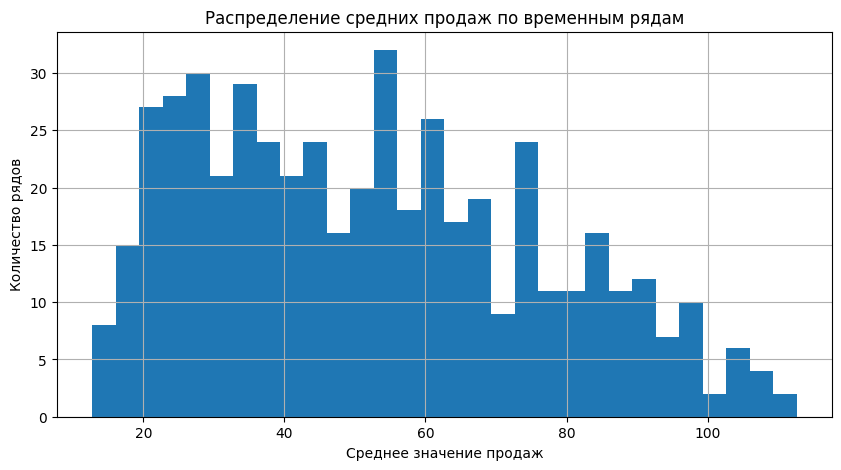

Сохранено: /content/drive/MyDrive/time_series_final_project/reports/figures/mean_sales_by_series_distribution.png


In [ ]:
fig_path = FIGURES_DIR / "mean_sales_by_series_distribution.png"

plt.figure(figsize=(10, 5))
plt.hist(scale_stats["mean"], bins=30)
plt.title("Распределение средних продаж по временным рядам")
plt.xlabel("Среднее значение продаж")
plt.ylabel("Количество рядов")
plt.grid(True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено:", fig_path)

**График стандартного отклонения**

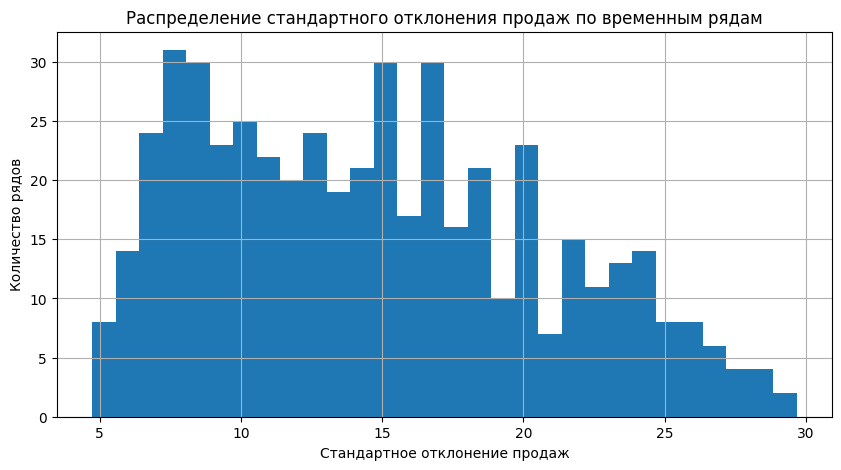

Сохранено: /content/drive/MyDrive/time_series_final_project/reports/figures/std_sales_by_series_distribution.png


In [ ]:
fig_path = FIGURES_DIR / "std_sales_by_series_distribution.png"

plt.figure(figsize=(10, 5))
plt.hist(scale_stats["std"], bins=30)
plt.title("Распределение стандартного отклонения продаж по временным рядам")
plt.xlabel("Стандартное отклонение продаж")
plt.ylabel("Количество рядов")
plt.grid(True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено:", fig_path)

**Средний спрос для каждой пары магазин–товар**

item,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50
store,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,19.971522,53.148959,33.208105,19.956188,16.612815,53.060789,52.783680,69.472070,46.504929,66.354326,63.217963,63.233844,76.159365,53.148959,79.680723,23.332421,29.972070,76.345564,36.676889,42.890471,36.176342,72.781490,26.469880,60.000000,72.736035,43.236035,20.050931,79.566813,63.086528,36.318182,53.008215,39.837897,62.755750,23.274918,59.495071,69.309967,26.424425,73.344469,39.694962,26.443593,20.002738,33.105696,46.242607,26.594195,72.720701,52.845016,19.814348,46.546002,26.461665,59.342826
2,28.173604,75.316539,46.992333,28.234940,23.540526,74.945235,75.058598,99.090361,65.478094,94.097481,89.309967,89.350493,107.903067,75.359803,112.578861,32.950164,42.568456,108.117196,51.819825,60.978094,51.756298,103.009858,37.569003,84.782585,103.426068,61.103505,28.338992,112.638007,88.973713,51.825301,75.276561,56.755203,89.311610,33.091457,84.662651,98.770537,37.359255,103.249179,56.164294,37.570646,28.069551,47.368018,65.785323,37.785871,103.381161,75.219606,28.187842,66.028478,37.711939,84.622125
3,25.070099,66.804491,41.771084,25.116101,20.857612,67.007119,66.647864,87.517525,58.486857,83.387733,79.291347,79.083790,96.214677,66.841183,100.423330,29.142935,37.753012,96.090909,45.854326,54.243702,45.955641,91.845564,33.389923,75.153888,91.839540,54.194962,25.090909,100.143483,79.681818,45.948521,66.974261,50.039430,79.129244,29.092004,74.623220,87.758488,33.440854,91.871851,50.173056,33.569003,24.989047,41.797371,58.197700,33.386090,91.851041,66.748083,25.120482,58.700986,33.259584,74.958379
4,22.938664,61.715225,38.548193,23.086528,19.525192,61.270537,61.625411,80.819825,54.043812,77.047645,73.400876,73.102957,88.604600,61.756846,92.653888,27.176889,34.552026,88.501643,42.435926,50.022453,42.294633,84.634173,30.737130,69.119387,85.022453,49.901972,23.111720,92.552574,73.243702,42.488499,61.308872,46.062979,73.378423,27.001095,68.970427,81.026835,30.736583,84.574480,46.168127,30.555312,23.168127,38.539978,54.018620,30.952355,84.687295,61.420044,23.114458,53.765608,30.840635,68.921687
5,16.739321,44.488499,27.835706,16.776561,14.086528,44.564622,44.535597,58.565717,38.837349,55.509858,52.980285,53.049288,64.395947,44.912377,66.987404,19.389376,25.067360,64.080504,30.704819,36.347755,30.491785,61.388280,22.348850,50.146769,61.200438,36.355969,16.763417,66.980832,52.775465,30.738773,44.698248,33.257393,53.157174,19.648412,50.182913,58.565717,22.289157,61.348302,33.232202,22.109529,16.830778,27.730559,39.163198,22.415115,61.427163,44.734940,16.699343,39.281490,22.371851,50.319277


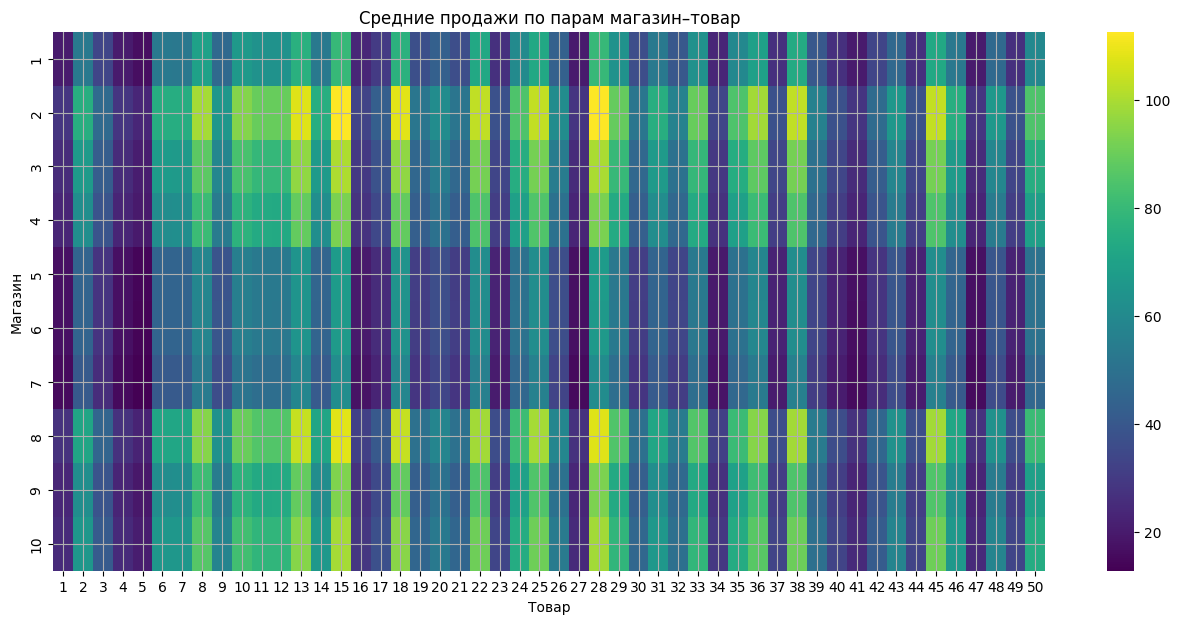

Сохранено: /content/drive/MyDrive/time_series_final_project/reports/figures/store_item_mean_sales_heatmap.png


In [ ]:
# Heatmap средних продаж store × item

import seaborn as sns

cross_sales = df_eda.pivot_table(
    index="store",
    columns="item",
    values="y",
    aggfunc="mean"
)

display(cross_sales.head())

fig_path = FIGURES_DIR / "store_item_mean_sales_heatmap.png"

plt.figure(figsize=(16, 7))
sns.heatmap(cross_sales, cmap="viridis")
plt.title("Средние продажи по парам магазин–товар")
plt.xlabel("Товар")
plt.ylabel("Магазин")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено:", fig_path)

Для анализа различий спроса между магазинами и товарами была построена heatmap средних продаж по матрице `store × item`.

График показывает, что уровень спроса зависит и от магазина, и от товара. Некоторые товары имеют стабильно высокий спрос в большинстве магазинов, а магазины 2 и 8 в целом демонстрируют более высокий уровень средних продаж. Магазины 5, 6 и 7 имеют более низкий масштаб продаж.

Этот результат подтверждает, что пара `store-item` является корректной единицей временного ряда. Также он показывает необходимость использовать признаки `store` и `item` при построении глобальных моделей